<a href="https://colab.research.google.com/github/Yalda-Ashrafi/ICA-Independent-Component-Analysis-/blob/main/ICA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from sklearn.decomposition import FastICA
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
import pandas as pd
data=pd.read_csv('surveyData.csv')
data.head()

/tmp/ipykernel_891/214114443.py:2: DtypeWarning: Columns (0,18,31,45,50,63,80,92,99,105,130,171,187,206,241,254,266,278,289,290,307,322,330,342,353) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('surveyData.csv')


,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q35_B_Part_2,Q35_B_Part_3,Q35_B_Part_4,Q35_B_Part_5,Q35_B_Part_6,Q35_B_Part_7,Q35_B_Part_8,Q35_B_Part_9,Q35_B_Part_10,Q35_B_OTHER
0,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,1838,35-39,Man,Colombia,Doctoral degree,Student,5-10 years,Python,R,SQL,...,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN,NaN
2,289287,30-34,Man,United States of America,Master’s degree,Data Engineer,5-10 years,Python,R,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,860,35-39,Man,Argentina,Bachelor’s degree,Software Engineer,10-20 years,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,507,30-34,Man,United States of America,Master’s degree,Data Scientist,5-10 years,Python,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Columns: 355 entries, Time from Start to Finish (seconds) to Q35_B_OTHER
dtypes: object(355)
memory usage: 29.0+ MB


In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import FastICA

# Copy dataset
df = data.copy()

# Fill missing values
df = df.fillna("Unknown")

# Convert object columns to numeric
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Apply ICA
ICA = FastICA(n_components=2, random_state=42)

IndependentComp_values = ICA.fit_transform(data.values)

print(IndependentComp_values[:5])

ValueError: could not convert string to float: 'Duration (in seconds)'

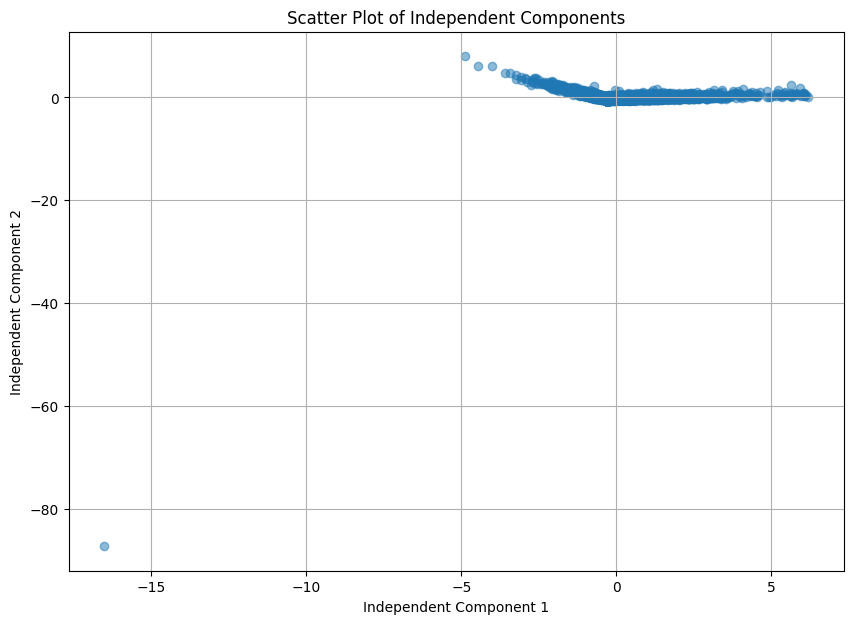

In [10]:
plt.figure(figsize=(10, 7))
plt.scatter(IndependentComp_values[:, 0], IndependentComp_values[:, 1], alpha=0.5)
plt.title('Scatter Plot of Independent Components')
plt.xlabel('Independent Component 1')
plt.ylabel('Independent Component 2')
plt.grid(True)
plt.show()

In [12]:
print("## Final Independent Component ")
reducedata=pd.DataFrame(IndependentComp_values, columns=['IC1','IC2'])
print(reducedata.head(10))

## Final Independent Component 
         IC1        IC2
0 -16.538497 -87.233115
1   2.336515   0.369112
2  -1.187100   1.083251
3  -0.287219  -0.167601
4  -0.877304   0.432383
5  -0.268541  -0.579261
6  -0.273696  -0.440885
7   1.006815   0.071533
8   0.066427  -0.406671
9  -0.979802   0.810327
